In [2]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

QUESTIONS_PATH = "data/raw/LaMP_2/train_questions.json"
OUTPUTS_PATH = "data/raw/LaMP_2/train_outputs.json"

In [15]:
print("Loading questions...")
with open(QUESTIONS_PATH, "r", encoding='utf-8') as file:
    questions_data = json.load(file)

print("Loading outputs...")
with open(OUTPUTS_PATH, "r", encoding='utf-8') as file:
    questions_output = json.load(file)

print(f"Total question samples: {len(questions_data):,}")
print(f"Total output samples:   {len(questions_output['golds'] if isinstance(questions_output, dict) and 'golds' in questions_output else len(questions_output)):,}")

print(questions_data[:10])

for key, value in questions_output.items():
    if key == "golds":
        print(f"{key}")
        for gold_item in value[:30]:
            print(gold_item)
            print()
    else:
        print(f"{key}: {value}")





Loading questions...
Loading outputs...
Total question samples: 3,820
Total output samples:   3,820
[{'id': '100', 'input': "Which tag does this movie relate to among the following tags? Just answer with the tag name without further explanation. tags: [sci-fi, based on a book, comedy, action, twist ending, dystopia, dark comedy, classic, psychology, fantasy, romance, thought-provoking, social commentary, violence, true story] description: Annie Wilson, young widow and mother of three, makes her living foretelling others' futures\u2060—though her own has become cloudier than even she can see. Threatened by a client's violent husband and plagued by visions of a missing local woman, Annie finds herself pulled into a thicket of lies and deception in which her extraordinary gift may ultimately get her killed.", 'profile': [{'tag': 'comedy', 'description': "Major Benson Winifred Payne is being discharged from the Marines. Payne is a killin' machine, but the wars of the world are no longer fo

In [17]:
sample = questions_data[1]

print(sample.keys())

print("SAMPLE ID")
print(sample['id'])

print("TARGET QUERY")
print(sample.get("input"))

print("PROFILE")
print(sample.get("profile"))



dict_keys(['id', 'input', 'profile'])
SAMPLE ID
101
TARGET QUERY
Which tag does this movie relate to among the following tags? Just answer with the tag name without further explanation. tags: [sci-fi, based on a book, comedy, action, twist ending, dystopia, dark comedy, classic, psychology, fantasy, romance, thought-provoking, social commentary, violence, true story] description: Held in an L.A. interrogation room, Verbal Kint attempts to convince the feds that a mythic crime lord, Keyser Soze, not only exists, but was also responsible for drawing him and his four partners into a multi-million dollar heist that ended with an explosion in San Pedro harbor – leaving few survivors. Verbal lures his interrogators with an incredible story of the crime lord's almost supernatural prowess.
PROFILE
[{'tag': 'sci-fi', 'description': 'A wealthy entrepreneur secretly creates a theme park featuring living dinosaurs drawn from prehistoric DNA. Before opening day, he invites a team of experts and his

In [18]:
golds = questions_output["golds"] if isinstance(questions_output, dict) and "golds" in questions_output else questions_output
output_map = {item["id"]: item["output"] for item in golds}
sample_id = sample["id"]
print(f"Query for ID {sample_id}:")
print(sample.get("input")[:150] + "...")
print(f"\nGround Truth Output: '{output_map.get(sample_id)}'")

Query for ID 101:
Which tag does this movie relate to among the following tags? Just answer with the tag name without further explanation. tags: [sci-fi, based on a boo...

Ground Truth Output: 'comedy'


--- User Profile Size Statistics ---
Min items:    4
Max items:    1289
Mean items:   204.46
Median items: 44.00


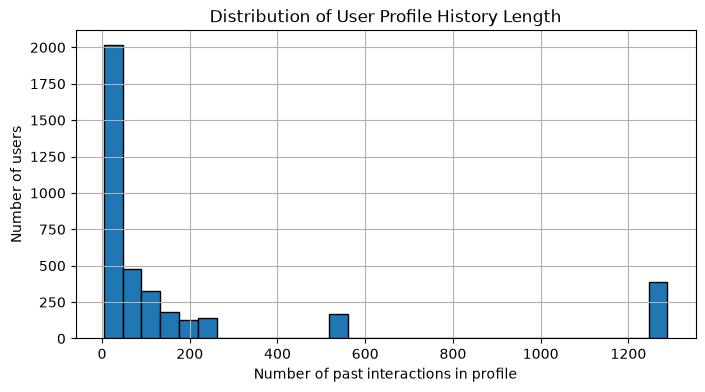

In [19]:
profile_lengths = [len(item.get("profile", [])) for item in questions_data]
df_stats = pd.Series(profile_lengths)
print("--- User Profile Size Statistics ---")
print(f"Min items:    {df_stats.min()}")
print(f"Max items:    {df_stats.max()}")
print(f"Mean items:   {df_stats.mean():.2f}")
print(f"Median items: {df_stats.median():.2f}")
plt.figure(figsize=(8, 4))
df_stats.hist(bins=30, edgecolor="black")
plt.title("Distribution of User Profile History Length")
plt.xlabel("Number of past interactions in profile")
plt.ylabel("Number of users")
plt.show()

In [25]:
profile = sample.get("profile")
print(profile)
print(f"Profile History for Sample ID: {sample['id']}\n" + "="*60)
for idx, history_item in enumerate(profile[:3]):
    print(f"\n[History Item #{idx+1}]")
    for key, value in history_item.items():
        print(f"  {key}: {value}")

[{'tag': 'sci-fi', 'description': 'A wealthy entrepreneur secretly creates a theme park featuring living dinosaurs drawn from prehistoric DNA. Before opening day, he invites a team of experts and his two eager grandchildren to experience the park and help calm anxious investors. However, the park is anything but amusing as the security systems go off-line and the dinosaurs escape.', 'id': '1010'}, {'tag': 'sci-fi', 'description': "Thirty years ago, aliens arrive on Earth. Not to conquer or give aid, but to find refuge from their dying planet. Separated from humans in a South African area called District 9, the aliens are managed by Multi-National United, which is unconcerned with the aliens' welfare but will do anything to master their advanced technology. When a company field agent contracts a mysterious virus that begins to alter his DNA, there is only one place he can hide: District 9.", 'id': '1011'}, {'tag': 'sci-fi', 'description': 'A highly intelligent chimpanzee named Caesar ha